In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

## Load data

In [2]:
# Collect metrics for plotting
metrics_dict = {}

# Load saved predictions 
models = [
    "132kb_human", 
    "132kb_mouse", 
    "132kb_human_mouse", 
    "132kb_human_mouse_rat", 
    "196kb_human_mouse_rat", 
    "524kb_human_mouse", 
    "524kb_human_mouse_rat"
]
for model in models:
    for pred_sps in ["rat", "mouse", "human"]:
        # Construct prediction directory path
        pred_dir = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{model}/preds_{pred_sps}"
        # Infer trained species from model name
        model_sps = model.split("_")[1:]
        for sps in model_sps:
            print(f"Model: {model}, Prediction Species: {pred_sps}, Model Species: {sps}")
            # Load predictions
            metrics_fn = f"{pred_dir}/metrics.json"
            if os.path.exists(metrics_fn):
                print(f"  Loading metrics from {metrics_fn}")
                with open(metrics_fn, "r") as f:
                    metrics = json.load(f)
                # Collect metrics for plotting (only if file exists)
                metrics_dict[(model, pred_sps, sps)] = metrics
            else:
                print(f"  Skipping - file not found: {metrics_fn}")

Model: 132kb_human, Prediction Species: rat, Model Species: human
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human/preds_rat/metrics.json
Model: 132kb_human, Prediction Species: mouse, Model Species: human
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human/preds_mouse/metrics.json
Model: 132kb_human, Prediction Species: human, Model Species: human
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human/preds_human/metrics.json
Model: 132kb_mouse, Prediction Species: rat, Model Species: mouse
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse/preds_rat/metrics.json
Model: 132kb_mouse, Prediction Species: mouse, Model Species: mouse
  Loading metrics from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse/preds_mouse/metrics.json
Model: 132kb_mouse, Prediction Species: human, Model Species: mouse
  Loading metri

In [3]:
# Colors for plotting
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'binary (any)'}
CLASS_COLORS = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}
TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

MODEL_COLORS = {
    # 132kb individual - lightest
    "132kb_human": "#d3d3d3",
    "132kb_mouse": "#cecece",
    "132kb_human (head: human)": "#9ecae1",
    "132kb_mouse (head: mouse)": "#fdd0a2",
    
    # 132kb human_mouse - medium
    "132kb_human_mouse": "#a9a9a9",
    "132kb_human_mouse (head: human)": "#4292c6",
    "132kb_human_mouse (head: mouse)": "#e08214",    
    
    # 132kb human_mouse_rat - medium-dark
    "132kb_human_mouse_rat": "#808080",
    "132kb_human_mouse_rat (head: human)": "#2171b5",
    "132kb_human_mouse_rat (head: mouse)": "#cc6e1a",
    "132kb_human_mouse_rat (head: rat)": "#d41f1f",
    
    # 196kb human_mouse_rat - slightly darker
    "196kb_human_mouse_rat": "#6b6b6b",
    "196kb_human_mouse_rat (head: human)": "#1a5fa0",
    "196kb_human_mouse_rat (head: mouse)": "#b86015",
    "196kb_human_mouse_rat (head: rat)": "#c41818",

    # 524kb human_mouse - dark
    "524kb_human_mouse": "#555555",
    "524kb_human_mouse (head: human)": "#08519c",
    "524kb_human_mouse (head: mouse)": "#b35806",
    
    # 524kb human_mouse_rat - darkest
    "524kb_human_mouse_rat": "#2a2a2a",
    "524kb_human_mouse_rat (head: human)": "#05387b",
    "524kb_human_mouse_rat (head: mouse)": "#8b3f00",
    "524kb_human_mouse_rat (head: rat)": "#7f0000"
}

# Explicit combo order for all usage plots
COMBO_ORDER = [
    "132kb_human (head: human)",
    "132kb_human_mouse (head: human)",
    "132kb_human_mouse_rat (head: human)",
    "196kb_human_mouse_rat (head: human)",
    "524kb_human_mouse (head: human)",
    "524kb_human_mouse_rat (head: human)",
    "132kb_mouse (head: mouse)",
    "132kb_human_mouse (head: mouse)",
    "132kb_human_mouse_rat (head: mouse)",
    "196kb_human_mouse_rat (head: mouse)",
    "524kb_human_mouse (head: mouse)",
    "524kb_human_mouse_rat (head: mouse)",
    "132kb_human_mouse_rat (head: rat)",
    "196kb_human_mouse_rat (head: rat)",
    "524kb_human_mouse_rat (head: rat)"
]

MODEL_ORDER = [
    "132kb_human", "132kb_mouse", "132kb_human_mouse", "132kb_human_mouse_rat", 
    "524kb_human_mouse", "524kb_human_mouse_rat",
]
HEAD_ORDER = ["human", "mouse", "rat"]

def combo_sort_key(combo):
    return COMBO_ORDER.index(combo) if combo in COMBO_ORDER else len(COMBO_ORDER)

## Splice site classification (AUPRC per class)

In [4]:
# Extract classification metrics (AUPRC per class)
classification_data = []

# Mapping from class names to indices
class_name_to_idx = {
    'Donor+': 0,
    'Acceptor+': 1,
    'Donor-': 2,
    'Acceptor-': 3
}

for (model, pred_sps, model_sps), metrics in metrics_dict.items():
    if pred_sps in metrics:
        species_metrics = metrics[pred_sps]
        
        # Per-class AUPRC (stored in "per_class_auprc" dict)
        if 'per_class_auprc' in species_metrics:
            for class_name, auprc_value in species_metrics['per_class_auprc'].items():
                class_idx = class_name_to_idx.get(class_name)
                if class_idx is not None:
                    classification_data.append({
                        'model': model,
                        'pred_species': pred_sps,
                        'model_species': model_sps,
                        'class_idx': class_idx,
                        'class_label': CLASS_LABELS[class_idx],
                        'auprc': auprc_value
                    })
        
        # Binary AUPRC (any splice site vs background)
        if 'binary_auprc' in species_metrics:
            classification_data.append({
                'model': model,
                'pred_species': pred_sps,
                'model_species': model_sps,
                'class_idx': 4,
                'class_label': 'binary (any)',
                'auprc': species_metrics['binary_auprc']
            })

df_classification = pd.DataFrame(classification_data)
print(f"Extracted {len(df_classification)} classification metrics")
df_classification.head(10)

Extracted 225 classification metrics


,model,pred_species,model_species,class_idx,class_label,auprc
0,132kb_human,rat,human,0,donor +,0.850366
1,132kb_human,rat,human,1,acceptor +,0.823141
2,132kb_human,rat,human,2,donor -,0.849335
3,132kb_human,rat,human,3,acceptor -,0.853405
4,132kb_human,rat,human,4,binary (any),0.873736
5,132kb_human,mouse,human,0,donor +,0.779130
6,132kb_human,mouse,human,1,acceptor +,0.779592
7,132kb_human,mouse,human,2,donor -,0.762455
8,132kb_human,mouse,human,3,acceptor -,0.762337
9,132kb_human,mouse,human,4,binary (any),0.879741


Plot grouped barplot of classification AUPRC

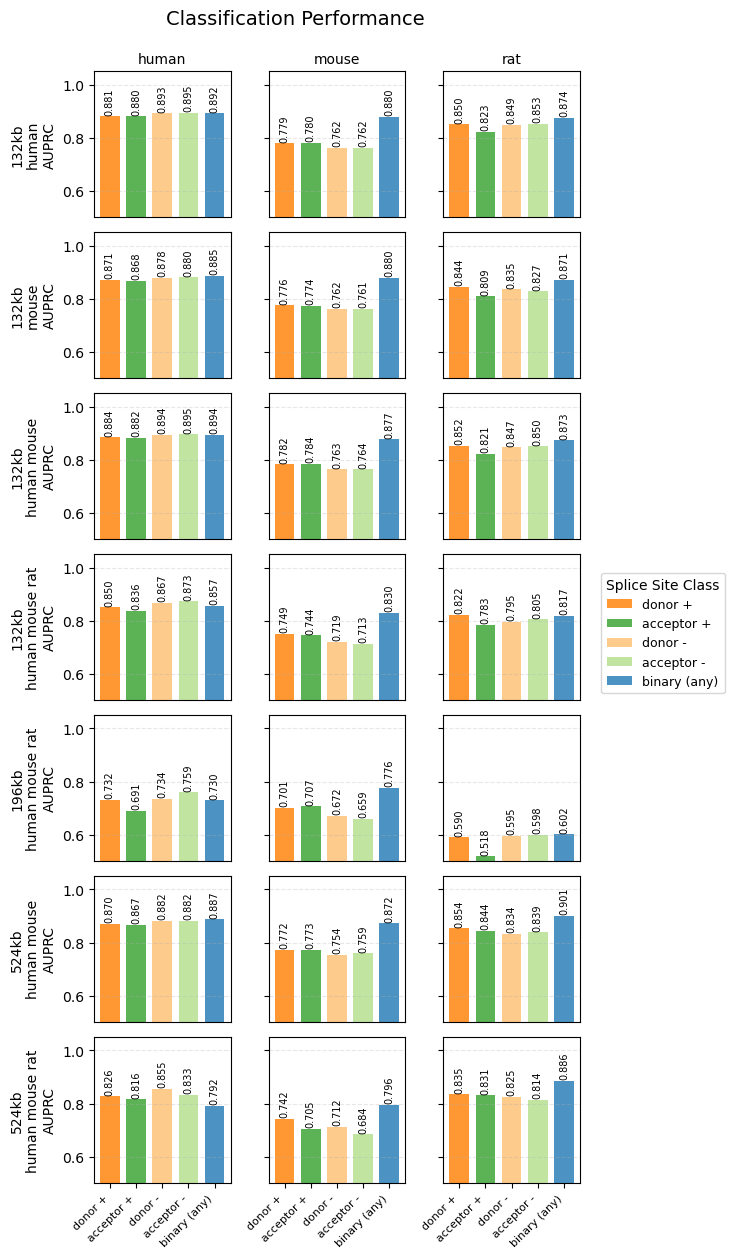

In [5]:
# Grouped barplot: Classification AUPRC by class, organized in grid
# Rows = models, Columns = evaluation species
import matplotlib.pyplot as plt
import numpy as np

# Get unique models and prediction species
pred_species_list = sorted(df_classification['pred_species'].unique())
classes = sorted(df_classification['class_idx'].unique())

n_models = len(models)
n_species = len(pred_species_list)
n_classes = len(classes)

# Create subplot grid: rows = models, cols = species
fig, axes = plt.subplots(n_models, n_species, figsize=(n_species * 2, n_models * 1.8),
                         squeeze=False, sharex=False, sharey=True)

bar_width = 0.25
x = np.arange(n_classes)

# Plot each model × species combination
for model_idx, model in enumerate(models):
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[model_idx, species_idx]

        # Filter data for this model and species
        subset = df_classification[
            (df_classification['model'] == model) &
            (df_classification['pred_species'] == pred_sps)
        ]

        if len(subset) > 0:
            # Plot bars for each class
            for i, class_idx in enumerate(classes):
                class_data = subset[subset['class_idx'] == class_idx]

                if len(class_data) > 0:
                    auprc_value = class_data['auprc'].values[0]

                    # Use class colors
                    color = CLASS_COLORS.get(class_idx, '#888888')
                    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
                    if class_idx == 4:  # Binary
                        label = 'binary'
                        color = '#1f78b4'

                    bar = ax.bar(i, auprc_value, bar_width * 3, color=color, alpha=0.8,
                          label=label if model_idx == 0 and species_idx == 0 else "")

                    # Add value on top of bar
                    ax.text(i, auprc_value + 0.005, f'{auprc_value:.3f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)

        # Customize subplot
        ax.set_ylim(0.5, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Set title for top row (species names)
        if model_idx == 0:
            ax.set_title(pred_sps, fontsize=10)

        # Set ylabel for leftmost column (model names)
        if species_idx == 0:
            # Split model name for better display
            seq_len = model.split("_")[0]
            sps = " ".join(model.split("_")[1:])
            ax.set_ylabel(f'{seq_len}\n{sps}\nAUPRC', fontsize=10)

        # Only show x-ticks on bottom row
        if model_idx == n_models - 1:
            ax.set_xticks(range(n_classes))
            ax.set_xticklabels([CLASS_LABELS.get(c, 'binary')[:12] for c in classes],
                              rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticks([])

# Add overall title
fig.suptitle('Classification Performance', fontsize=14, y=0.995)

# Create legend (only once, outside subplots)
handles = []
labels = []
for class_idx in classes:
    color = CLASS_COLORS.get(class_idx, '#888888')
    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
    if class_idx == 4:
        label = 'binary (any)'
        color = '#1f78b4'
    handles.append(plt.Rectangle((0,0),1,1, fc=color, alpha=0.8))
    labels.append(label)

fig.legend(handles, labels, title='Splice Site Class',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


Plot all models per class

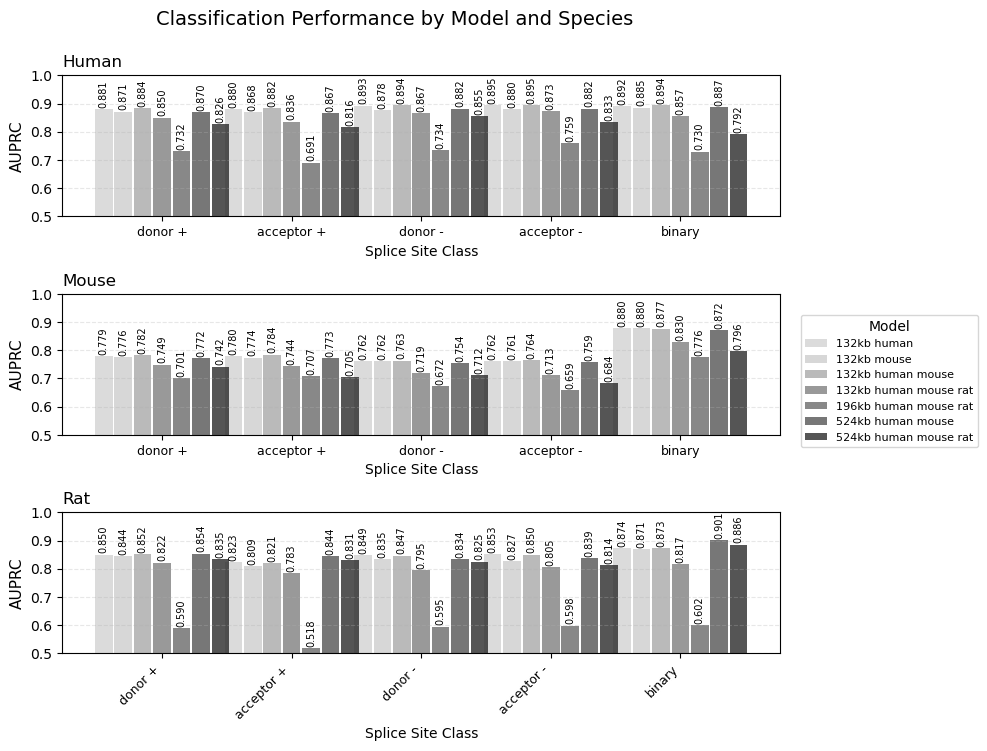

In [6]:
# Grouped barplot: classes grouped by model, one plot per species
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

models_classification = ["132kb_human", "132kb_mouse", "132kb_human_mouse", "132kb_human_mouse_rat", "196kb_human_mouse_rat", "524kb_human_mouse", "524kb_human_mouse_rat"]

# Subset those models for which we have data
models_classification = [model for model in models_classification if model in df_classification['model'].unique()]

# Get unique prediction species and classes
pred_species_list = sorted(df_classification['pred_species'].unique())
classes = sorted(df_classification['class_idx'].unique())
n_classes = len(classes)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    
    # Filter data for this species
    species_data = df_classification[df_classification['pred_species'] == pred_sps]
    
    # Get models present for this species, in the defined order
    models_present = [m for m in models_classification if m in species_data['model'].unique()]
    n_models = len(models_present)
    
    # Spacing parameters
    bar_width = 0.15
    class_spacing = 1.0
    
    for model_idx, model in enumerate(models_present):
        model_data = species_data[species_data['model'] == model]
        color = MODEL_COLORS[model]
        
        for class_idx, cls in enumerate(classes):
            class_data = model_data[model_data['class_idx'] == cls]
            
            if len(class_data) > 0:
                auprc_value = class_data['auprc'].values[0]
                
                # Position: class group + model offset within group
                x_pos = class_idx * class_spacing + model_idx * bar_width
                
                ax.bar(x_pos, auprc_value, bar_width * 0.9, 
                       color=color, alpha=0.8,
                       label=model.replace('_', ' ') if class_idx == 0 else "")
                
                # Add value on top
                if auprc_value > 0.5:  # Only show if high enough
                    ax.text(x_pos, auprc_value + 0.005, f'{auprc_value:.3f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)
    
    # Customize subplot
    ax.set_ylim(0.5, 1)
    ax.set_ylabel('AUPRC', fontsize=11)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set x-ticks at the center of each class group
    tick_positions = [class_idx * class_spacing + (n_models * bar_width) / 2 - bar_width/2 
                     for class_idx in range(n_classes)]
    ax.set_xticks(tick_positions)
    
    # Create class labels
    class_labels = []
    for cls in classes:
        label = CLASS_LABELS.get(cls, f'class_{cls}')
        if cls == 4:
            label = 'binary'
        class_labels.append(label)
    
    if species_idx == n_species - 1:
        ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
    else:
        ax.set_xticklabels(class_labels, fontsize=9)
    ax.set_xlabel('Splice Site Class', fontsize=10)

fig.suptitle('Classification Performance by Model and Species', fontsize=14, y=0.995)

# Create model legend with colors
legend_handles = []
for model in models_classification:
    color = MODEL_COLORS[model]
    legend_handles.append(Patch(facecolor=color, alpha=0.8, label=model.replace('_', ' ')))

fig.legend(handles=legend_handles, title='Model',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

## Splice usage metrics (per-condition correlations)

In [7]:
# Extract per-condition usage correlations from saved predictions
# We'll compute correlations from the usage .npz files and map to tissues via metadata

from scipy.stats import pearsonr
from pathlib import Path

def get_pooled_r(metrics_entry, pred_sps, usage_head_species):
    """Look up the pooled Pearson r for a given species/head from metrics dict entry.
    usage_by_head keys may be either the bare species name ("human") or
    prefixed with "from_" ("from_human"), so we try both.
    """
    species_m = metrics_entry.get(pred_sps, {})
    by_head = species_m.get('usage_by_head', {})
    if by_head:
        # Try bare name first, then "from_<name>"
        for key in (usage_head_species, f"from_{usage_head_species}"):
            val = by_head.get(key, {}).get('usage_pearson_r')
            if val is not None:
                return val
        return None
    return species_m.get('usage_pearson_r', None)

usage_data_list = []

for (model, pred_sps, model_sps), metrics in metrics_dict.items():
    pred_dir = Path(f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{model}/preds_{pred_sps}")
    
    # Load usage metadata to map conditions to tissues
    species_map = {'human': 'Homo_sapiens', 'mouse': 'Mus_musculus', 'rat': 'Rattus_norvegicus'}
    metadata_path = Path(f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species_map[pred_sps]}/usage.json")
    
    if not metadata_path.exists():
        print(f"Metadata not found: {metadata_path}")
        continue
    
    with open(metadata_path) as f:
        usage_metadata = json.load(f)
    condition_labels = usage_metadata.get("condition_labels", {})
    idx_to_name = {int(v): k for k, v in condition_labels.items()}
    
    # Determine which usage files to load
    usage_files = []
    
    # Check for cross-species predictions (new format)
    if model_sps != pred_sps:
        # Cross-species evaluation with multiple heads
        if (pred_dir / f"usage_{pred_sps}_from_{model_sps}.npz").exists():
            usage_files.append((f"usage_{pred_sps}_from_{model_sps}.npz", model_sps))
    elif model_sps == pred_sps:
        # Same-species or old format
        usage_files.append((f"usage_{pred_sps}.npz", model_sps))
    
    for usage_file, usage_head_species in usage_files:
        usage_path = pred_dir / usage_file
        
        if not usage_path.exists():
            print(f"Usage file not found: {usage_path}")
            continue
        
        # Pooled Pearson r from metrics.json
        pooled_r = get_pooled_r(metrics, pred_sps, usage_head_species)
        
        # Load usage predictions
        usage_data = np.load(usage_path)
        
        # Compute per-condition correlations using summary statistics
        stats_cond_ids = usage_data['stats_cond_ids']
        stats_n = usage_data['stats_n']
        stats_sum_pred = usage_data['stats_sum_pred']
        stats_sum_true = usage_data['stats_sum_true']
        stats_sum_pred2 = usage_data['stats_sum_pred2']
        stats_sum_true2 = usage_data['stats_sum_true2']
        stats_sum_prod = usage_data['stats_sum_prod']
        
        for i, cond_idx in enumerate(stats_cond_ids):
            n = stats_n[i]
            if n <= 1:
                continue
            
            # Pearson r from summary statistics
            numerator = n * stats_sum_prod[i] - stats_sum_pred[i] * stats_sum_true[i]
            denom_pred = n * stats_sum_pred2[i] - stats_sum_pred[i] ** 2
            denom_true = n * stats_sum_true2[i] - stats_sum_true[i] ** 2
            
            if denom_pred > 0 and denom_true > 0:
                r = numerator / np.sqrt(denom_pred * denom_true)
            else:
                continue
            
            # Get condition name and extract tissue
            cond_name = idx_to_name.get(int(cond_idx), f"unknown_{cond_idx}")
            tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
            
            try:
                timepoint = int(cond_name.rsplit('_', 1)[1]) if '_' in cond_name else None
            except:
                timepoint = None
            
            usage_data_list.append({
                'model': model,
                'pred_species': pred_sps,
                'model_species': model_sps,
                'usage_head_species': usage_head_species,
                'tissue': tissue,
                'condition_idx': int(cond_idx),
                'condition_name': cond_name,
                'timepoint': timepoint,
                'correlation': float(r),
                'pooled_r': float(pooled_r) if pooled_r is not None else float('nan'),
                'n': int(n)
            })

df_usage_ = pd.DataFrame(usage_data_list)
print(f"Extracted {len(df_usage_)} per-condition usage correlations")
df_usage_.head(10)


Extracted 3474 per-condition usage correlations


,model,pred_species,model_species,usage_head_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n
0,132kb_human,rat,human,human,Brain,0,Brain_1,1,0.747879,0.528037,132082
1,132kb_human,rat,human,human,Brain,1,Brain_10,10,0.745903,0.528037,132082
2,132kb_human,rat,human,human,Brain,2,Brain_11,11,0.715231,0.528037,132082
3,132kb_human,rat,human,human,Brain,4,Brain_13,13,0.722864,0.528037,132082
4,132kb_human,rat,human,human,Brain,5,Brain_14,14,0.729407,0.528037,132082
5,132kb_human,rat,human,human,Brain,6,Brain_2,2,0.755127,0.528037,132082
6,132kb_human,rat,human,human,Brain,8,Brain_4,4,0.648894,0.528037,132082
7,132kb_human,rat,human,human,Brain,9,Brain_5,5,0.754416,0.528037,132082
8,132kb_human,rat,human,human,Brain,11,Brain_7,7,0.788722,0.528037,132082
9,132kb_human,rat,human,human,Brain,12,Brain_8,8,0.572769,0.528037,132082


Load usage data for all species and conditions.

In [8]:
data_json_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/data_config_orthologs.json"
with open(data_json_fn, 'r') as f:
    data_config = json.load(f)

species_list = list(data_config.keys())
species_list = ['human', 'mouse', 'rat']

usage_dfs = {}
for sps in species_list:
    parquet_path = os.path.expanduser(data_config[sps]["usage_parquet"])
    if not os.path.exists(parquet_path):
        print(f"Not found: {parquet_path}")
        continue
    df = pd.read_parquet(parquet_path)
    usage_dfs[sps] = df
    print(f"{sps}: {len(df):,} rows, columns: {list(df.columns)}")

human: 66,671,282 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
mouse: 71,135,088 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rat: 69,754,030 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']


Count `n_sites` per condition and species.

In [9]:
# Build a tidy DataFrame: species × condition → n_sites
# Condition labels come from data_config; usage parquet has one row per site×condition

records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    counts = df[df[cond_col].isin(known_indices)].groupby(cond_col).size().reset_index(name="n_sites")
    for _, row in counts.iterrows():
        cond_idx = int(row[cond_col])
        records.append({
            "pred_species": sps,
            "condition_idx": cond_idx,
            "n_sites": int(row["n_sites"]),
        })

df_sites = pd.DataFrame(records)
print(f"Total rows: {len(df_sites)}")
df_sites.head(10)

# Make sure columns to merge in df_sites are the same type as in df_usage_
key_cols = ["pred_species", "condition_idx"]
for col in key_cols:
    if col in df_sites.columns and col in df_usage_.columns:
        df_sites[col] = df_sites[col].astype(df_usage_[col].dtype)

# Merge usage correlations with site counts
df_usage = df_usage_.merge(df_sites, on=key_cols, how="left")
df_usage['n_sites'] = df_usage['n_sites'].fillna(0).astype(int)
print(f"{len(df_usage)} usage records")
df_usage.head(10)

Total rows: 255
3474 usage records


,model,pred_species,model_species,usage_head_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n,n_sites
0,132kb_human,rat,human,human,Brain,0,Brain_1,1,0.747879,0.528037,132082,862202
1,132kb_human,rat,human,human,Brain,1,Brain_10,10,0.745903,0.528037,132082,979123
2,132kb_human,rat,human,human,Brain,2,Brain_11,11,0.715231,0.528037,132082,960956
3,132kb_human,rat,human,human,Brain,4,Brain_13,13,0.722864,0.528037,132082,934872
4,132kb_human,rat,human,human,Brain,5,Brain_14,14,0.729407,0.528037,132082,971987
5,132kb_human,rat,human,human,Brain,6,Brain_2,2,0.755127,0.528037,132082,924982
6,132kb_human,rat,human,human,Brain,8,Brain_4,4,0.648894,0.528037,132082,910699
7,132kb_human,rat,human,human,Brain,9,Brain_5,5,0.754416,0.528037,132082,919927
8,132kb_human,rat,human,human,Brain,11,Brain_7,7,0.788722,0.528037,132082,994748
9,132kb_human,rat,human,human,Brain,12,Brain_8,8,0.572769,0.528037,132082,971605


Plot boxplot of usage correlation by condition, groupped by condition

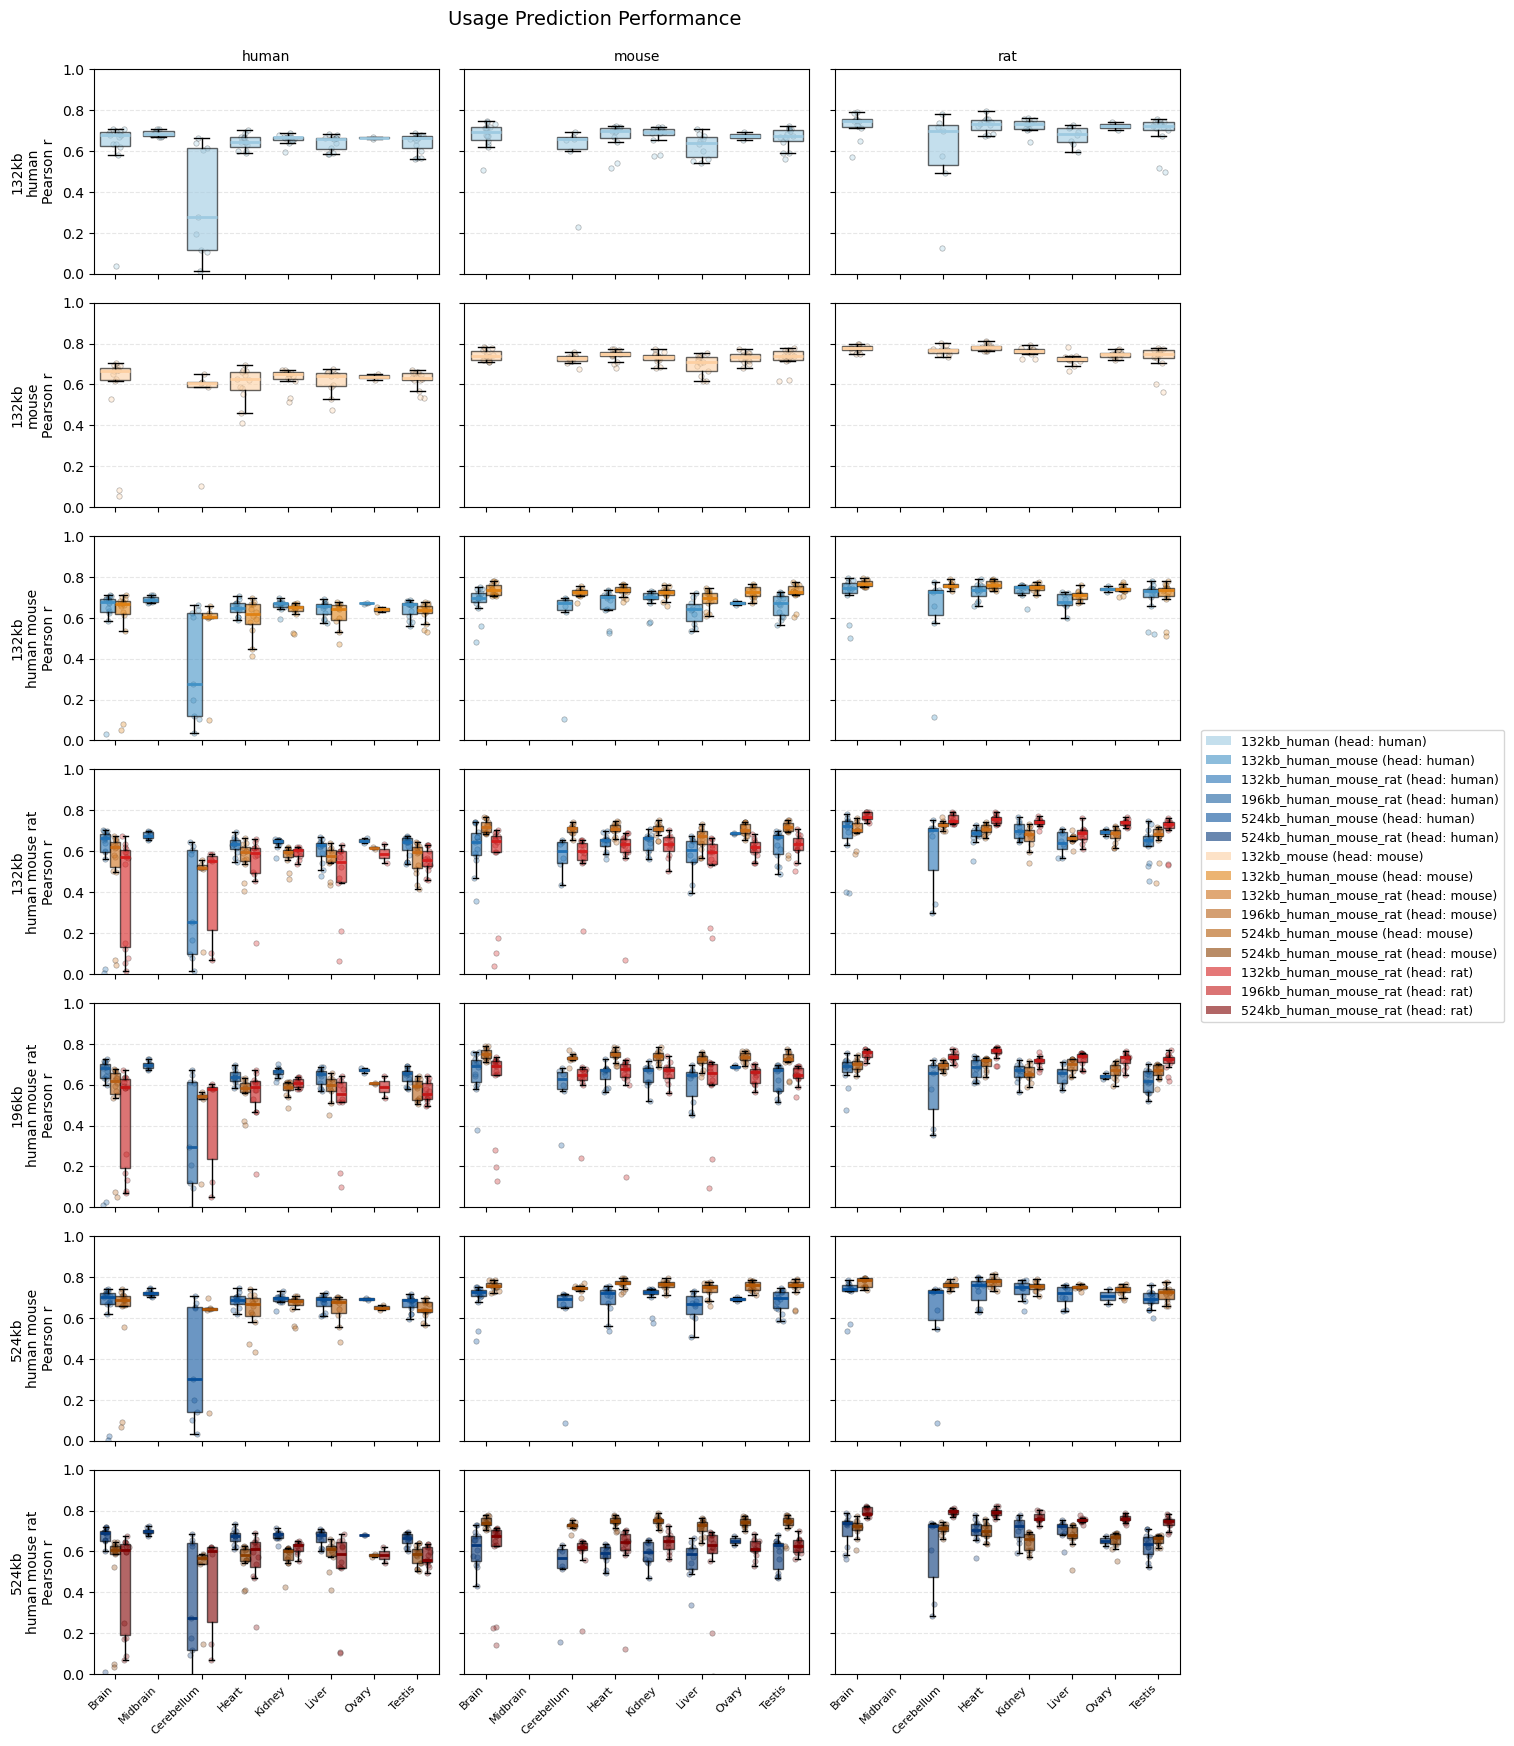

In [10]:
# Simplified grouped boxplot: Rows = models, Columns = evaluation species
# Only show model+head combos present in each subplot, align by tissue

pred_species_list = sorted(df_usage['pred_species'].unique())
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver',  'Ovary', 'Testis']
tissues = [t for t in tissues if t in df_usage['tissue'].unique()]
n_models = len(models)
n_species = len(pred_species_list)
n_tissues = len(tissues)

fig, axes = plt.subplots(n_models, n_species, figsize=(n_species * 4, n_models * 2.5),
                         squeeze=False, sharex=True, sharey=True)

for model_idx, model in enumerate(models):
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[model_idx, species_idx]
        # Find all model+head combos present for this model/species, ordered by COMBO_ORDER
        combos_present = df_usage[(df_usage['model'] == model) & (df_usage['pred_species'] == pred_sps)][['model', 'usage_head_species']]
        combos_present = combos_present.drop_duplicates().apply(lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1)
        combos_present = sorted(combos_present.unique(), key=combo_sort_key)
        n_combos = len(combos_present)
        if n_combos == 0:
            ax.axis('off')
            continue
        box_width = 0.7 / n_combos
        for combo_idx, combo in enumerate(combos_present):
            combo_model = combo.split(' (head:')[0]
            usage_head = combo.split('(head: ')[1].rstrip(')')
            subset = df_usage[(df_usage['pred_species'] == pred_sps) & (df_usage['model'] == model) & (df_usage['usage_head_species'] == usage_head)]
            box_data = []
            box_positions = []
            for tissue_idx, tissue in enumerate(tissues):
                tissue_data = subset[subset['tissue'] == tissue]
                if len(tissue_data) > 0:
                    box_data.append(tissue_data['correlation'].values)
                    pos = tissue_idx + 1 + (combo_idx - n_combos/2 + 0.5) * box_width
                    box_positions.append(pos)
                else:
                    box_data.append([])
                    pos = tissue_idx + 1 + (combo_idx - n_combos/2 + 0.5) * box_width
                    box_positions.append(pos)
            if any(len(bd) > 0 for bd in box_data):
                bp = ax.boxplot(
                    [bd if len(bd) > 0 else [np.nan] for bd in box_data],
                    positions=box_positions,
                    patch_artist=True,
                    showfliers=False,
                    widths=box_width
                )
                color = MODEL_COLORS.get(combo, '#888888')
                for patch in bp['boxes']:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.6)
                for median in bp['medians']:
                    median.set_color(color)
                    median.set_linewidth(2)
                for pos, bd in zip(box_positions, box_data):
                    if len(bd) > 0:
                        x_jitter = np.random.normal(pos, box_width * 0.12, size=len(bd))
                        ax.scatter(x_jitter, bd, alpha=0.3, s=15,
                                   color=color, edgecolors='black', linewidths=0.5)
        ax.set_ylim(0, 1)
        ax.set_xlim(0.5, n_tissues + 0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if model_idx == 0:
            ax.set_title(pred_sps, fontsize=10)
        if species_idx == 0:
            # Split model name for better display
            seq_len = model.split("_")[0]
            sps = " ".join(model.split("_")[1:])
            ax.set_ylabel(f'{seq_len}\n{sps}\nPearson r', fontsize=10)
        ax.set_xticks(range(1, n_tissues + 1))
        if model_idx == n_models - 1:
            ax.set_xticklabels([tissue[:10] for tissue in tissues], rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticklabels([])

fig.suptitle('Usage Prediction Performance', fontsize=14, y=0.995)

# Order legend by COMBO_ORDER
legend_combos = [c for c in COMBO_ORDER if c in df_usage[['model', 'usage_head_species']].apply(lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique()]
legend_handles = [Patch(facecolor=MODEL_COLORS.get(combo, '#888888'), alpha=0.6, label=combo) for combo in legend_combos]
fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
plt.show()


Single plot with all tissues on x-axis

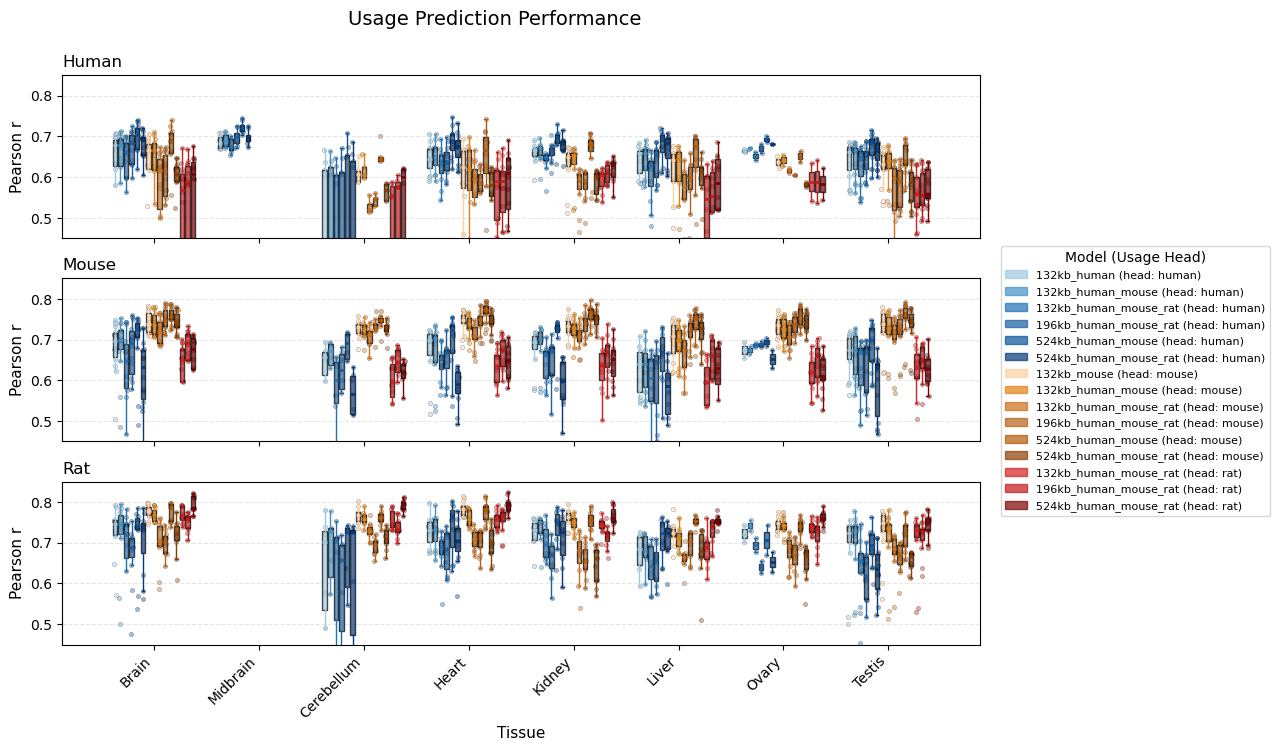

In [ ]:
# Alternative: Separate plots by prediction species (in rows), tissues on x-axis with grouped boxplots
import matplotlib.patches as mpatches

# Explicit combo order
COMBO_ORDER = [
    "132kb_human (head: human)",
    "132kb_human_mouse (head: human)",
    "132kb_human_mouse_rat (head: human)",
    "196kb_human_mouse_rat (head: human)",
    "524kb_human_mouse (head: human)",
    "524kb_human_mouse_rat (head: human)",
    "132kb_mouse (head: mouse)",
    "132kb_human_mouse (head: mouse)",
    "132kb_human_mouse_rat (head: mouse)",
    "196kb_human_mouse_rat (head: mouse)",
    "524kb_human_mouse (head: mouse)",
    "524kb_human_mouse_rat (head: mouse)",
    "132kb_human_mouse_rat (head: rat)",
    "196kb_human_mouse_rat (head: rat)",
    "524kb_human_mouse_rat (head: rat)"
]
def combo_sort_key(combo):
    return COMBO_ORDER.index(combo) if combo in COMBO_ORDER else len(COMBO_ORDER)

tissues = sorted(df_usage['tissue'].unique())
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver',  'Ovary', 'Testis'] 
pred_species_list = sorted(df_usage['pred_species'].unique())

# Get model+head combinations, order by COMBO_ORDER
model_head_combos = [c for c in COMBO_ORDER if c in df_usage[['model', 'usage_head_species']].apply(lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique()]

n_tissues = len(tissues)
n_species = len(pred_species_list)

# Exclude conditions
blacklist = [] #['Brain_4', 'Brain_8', 'Cerebellum_1', 'Cerebellum_2', 'Cerebellum_3', 'Cerebellum_14', 'Cerebellum_15']

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(10, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    
    # Filter data for this prediction species
    species_data = df_usage[df_usage['pred_species'] == pred_sps]
    
    # Get groups (model+head combos) for this species, ordered by COMBO_ORDER
    groups = [c for c in COMBO_ORDER if c in species_data[['model', 'usage_head_species']].apply(lambda x: f"{x['model']} (head: {x['usage_head_species']})", axis=1).unique()]
    n_groups = len(groups)
    box_width = 0.8 / n_groups if n_groups > 0 else 0.8
    
    for tissue_idx, tissue in enumerate(tissues):
        tissue_data = species_data[species_data['tissue'] == tissue]
        
        for group_idx, group in enumerate(groups):
            # Parse group to get model and usage_head
            model = group.split(' (head:')[0]
            usage_head = group.split('(head: ')[1].rstrip(')')
            
            group_data = tissue_data[
                (tissue_data['model'] == model) & 
                (tissue_data['usage_head_species'] == usage_head)
            ]
            
            # Exclude blacklisted conditions
            group_data = group_data[~group_data['condition_name'].isin(blacklist)]

            if len(group_data) > 0:
                correlations = group_data['correlation'].values
                
                # Position for this boxplot
                x_pos = tissue_idx + (group_idx - n_groups/2 + 0.5) * box_width
                
                # Create boxplot
                bp = ax.boxplot([correlations], positions=[x_pos], widths=box_width * 0.8,
                               patch_artist=True, showfliers=False,
                               boxprops=dict(facecolor=MODEL_COLORS[group], alpha=0.7),
                               medianprops=dict(color=MODEL_COLORS[group], linewidth=2),
                               whiskerprops=dict(color=MODEL_COLORS[group]),
                               capprops=dict(color=MODEL_COLORS[group]))
                
                # Add scatter points with jitter
                x_jitter = np.random.normal(x_pos, box_width * 0.1, size=len(correlations))
                ax.scatter(x_jitter, correlations, alpha=0.4, s=10,
                          color=MODEL_COLORS[group], edgecolors='black', linewidths=0.3)

    # Customize x-axis
    ax.set_xticks(range(n_tissues))
    # Only show x-tick labels on bottom subplot
    if species_idx == n_species - 1:
        ax.set_xticklabels(tissues, fontsize=10, rotation=45, ha='right')
        ax.set_xlabel('Tissue', fontsize=11)
    else:
        ax.set_xticklabels([])
    
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.set_ylim(0.45, 0.85)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Create legend outside on the right (same for all species), ordered by COMBO_ORDER
legend_patches = [mpatches.Patch(color=MODEL_COLORS[group], alpha=0.7, label=group) 
                  for group in model_head_combos]
fig.legend(handles=legend_patches, title='Model (Usage Head)', 
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

fig.suptitle('Usage Prediction Performance', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


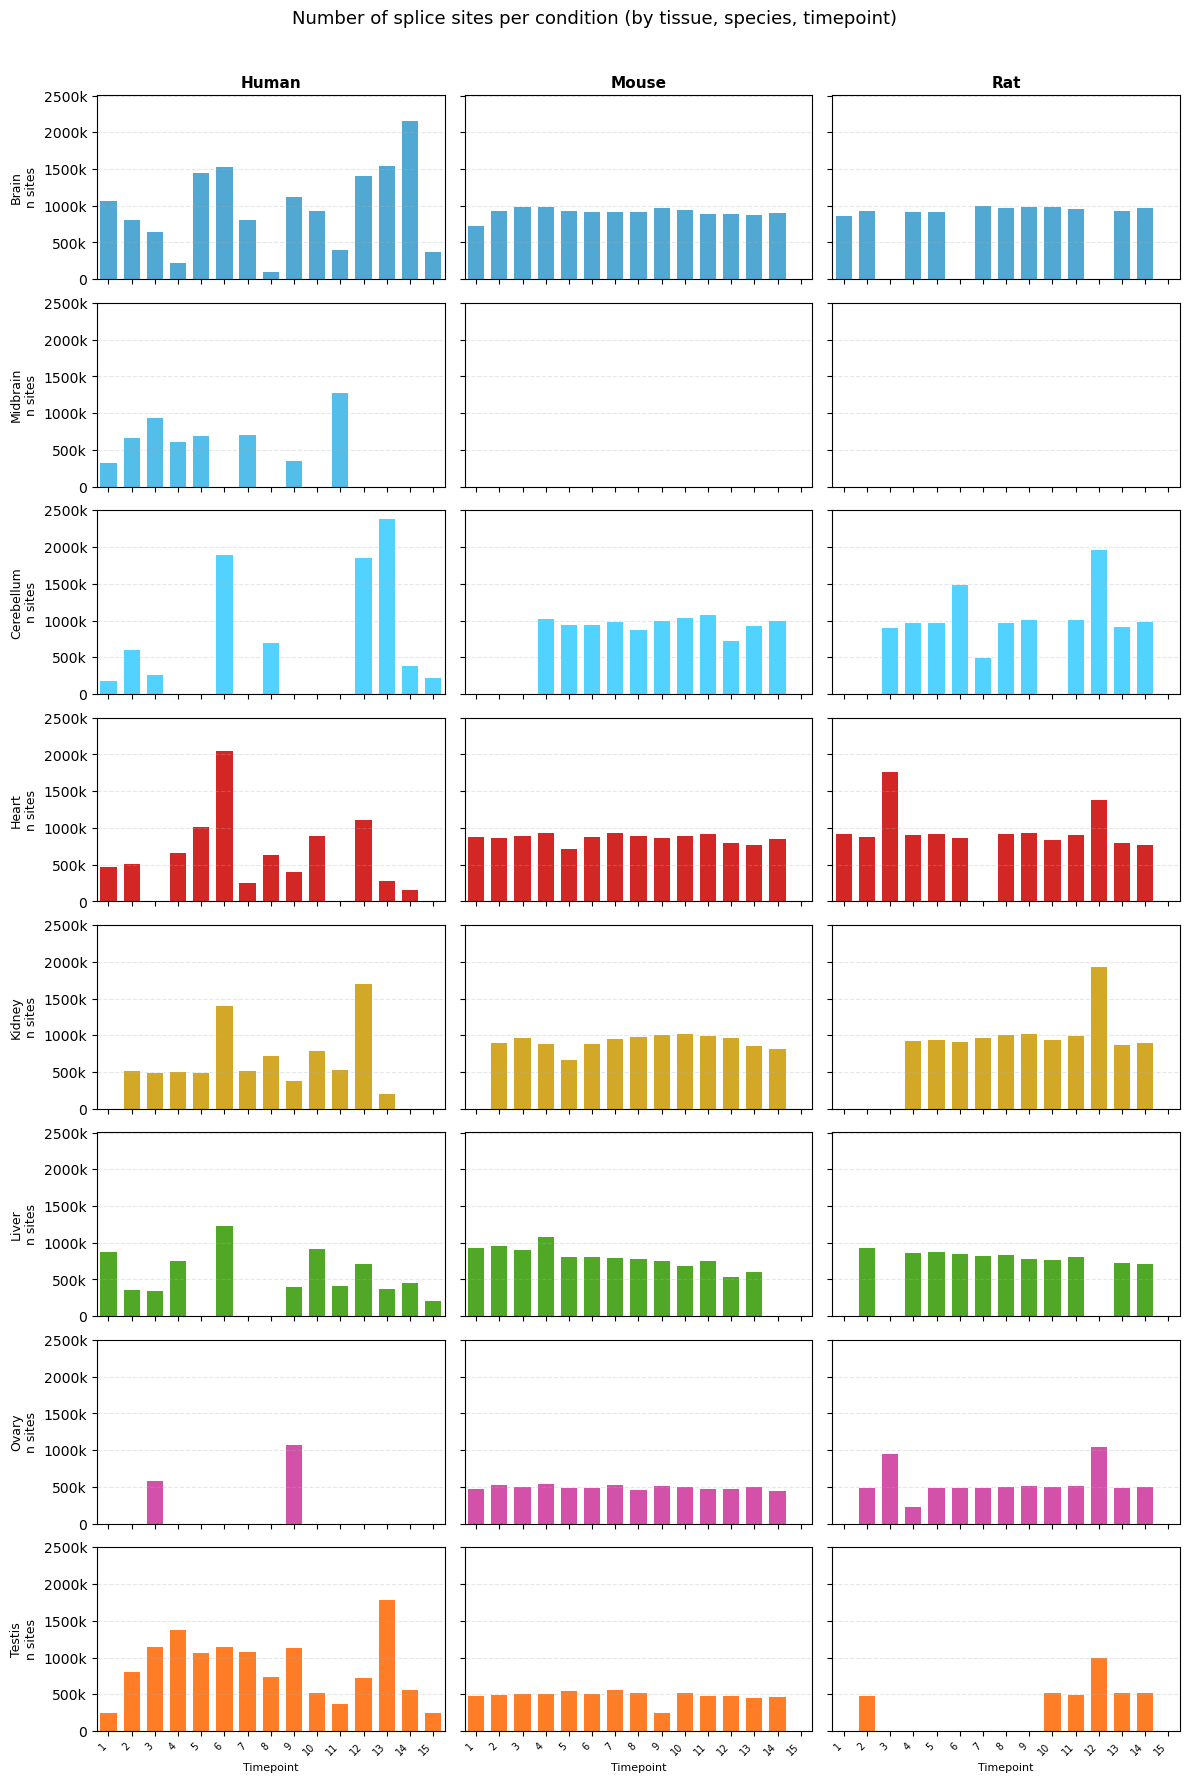

In [12]:
# Grid of n_sites per timepoint: rows = tissues, columns = species
# Each subplot: barplot of n_sites (y) per timepoint (x), colored by tissue

df_s = df_usage[['pred_species', 'tissue', 'timepoint', 'n_sites']].drop_duplicates()

TISSUE_ORDER = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Ovary', 'Testis']
SPECIES_ORDER = ['human', 'mouse', 'rat']

# Only keep tissues/species present in df_s
tissues = [t for t in TISSUE_ORDER if t in df_s['tissue'].unique()]
species_list = [s for s in SPECIES_ORDER if s in df_s['pred_species'].unique()]

n_tissues = len(tissues)
n_species = len(species_list)

# Get all unique timepoints (sorted)
all_timepoints = sorted(df_s['timepoint'].dropna().unique())

fig, axes = plt.subplots(n_tissues, n_species, figsize=(n_species * 4, n_tissues * 2.2), sharey=True, sharex=True, squeeze=False)

for r, tissue in enumerate(tissues):
    for c, sps in enumerate(species_list):
        ax = axes[r, c]
        sub = df_s[(df_s['tissue'] == tissue) & (df_s['pred_species'] == sps)]
        # Align bars to all_timepoints (fill missing with 0)
        tp_to_n = dict(zip(sub['timepoint'], sub['n_sites'])) if not sub.empty else {}
        heights = [tp_to_n.get(tp, 0) for tp in all_timepoints]
        ax.bar(range(len(all_timepoints)), heights, color=TISSUE_COLORS.get(tissue, '#888888'), alpha=0.85, width=0.7)
        ax.set_xlim(-0.5, len(all_timepoints) - 0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if r == 0:
            ax.set_title(sps.capitalize(), fontsize=11, fontweight='bold')
        if c == 0:
            ax.set_ylabel(f"{tissue}\nn sites", fontsize=9)
        if r == n_tissues - 1:
            ax.set_xticks(range(len(all_timepoints)))
            ax.set_xticklabels([str(tp) for tp in all_timepoints], rotation=45, ha='right', fontsize=7)
            ax.set_xlabel('Timepoint', fontsize=8)
        else:
            ax.set_xticks([])
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x))))

fig.suptitle('Number of splice sites per condition (by tissue, species, timepoint)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Scatterplot: n_sites vs correlation, colored by tissue, one row per species, one column per model
import matplotlib.patches as mpatches
import matplotlib as mpl

# Get all models present (ignore usage head)
models_present = sorted(df_usage['model'].unique())
pred_species_list = sorted(df_usage['pred_species'].unique())
pred_species_list = ['human']

fig, axes = plt.subplots(len(pred_species_list), len(models_present), figsize=(4 * len(models_present), 4 * len(pred_species_list)), sharey=True, sharex=True)
if len(pred_species_list) == 1:
    axes = [axes]
if len(models_present) == 1:
    axes = [[ax] for ax in axes]

for i, pred_sps in enumerate(pred_species_list):
    sps_data = df_usage[df_usage['pred_species'] == pred_sps]
    for j, model in enumerate(models_present):
        ax = axes[i][j]
        model_data = sps_data[sps_data['model'] == model]
        # Only plot the head matching the prediction species
        for usage_head in sorted(model_data['usage_head_species'].unique()):
            if usage_head != pred_sps:
                continue  
            sub = model_data[model_data['usage_head_species'] == usage_head]
            if sub.empty:
                continue
            # Color by tissue
            for tissue in sorted(sub['tissue'].unique()):
                if tissue not in ['Brain']:
                    continue
                tissue_sub = sub[sub['tissue'] == tissue]
                if tissue_sub.empty:
                    continue
                color = TISSUE_COLORS.get(tissue, '#888888')
                # Make dot size proportional to timepoint value (normalize for visibility)
                if 'timepoint' in tissue_sub.columns:
                    tp_min, tp_max = tissue_sub['timepoint'].min(), tissue_sub['timepoint'].max()
                    if tp_max > tp_min:
                        sizes = 32 + 128 * (tissue_sub['timepoint'] - tp_min) / (tp_max - tp_min)
                    else:
                        sizes = 64
                else:
                    sizes = 64
                sc = ax.scatter(tissue_sub['n_sites'], tissue_sub['correlation'], label=tissue, color=color, alpha=0.7, s=sizes)
                # Add timepoint labels to points with Pearson r < 0.35, centered on the point
                if 'timepoint' in tissue_sub.columns:
                    for idx, row in tissue_sub.iterrows():
                        if row['correlation'] < 0.35:
                            ax.text(row['n_sites'], row['correlation'], str(row['timepoint']), fontsize=8, color='black',
                                    ha='center', va='center', alpha=0.9,
                                    path_effects=[mpl.patheffects.withStroke(linewidth=2, foreground='white')])
        ax.set_xscale('log')
        if i == len(pred_species_list) - 1:
            ax.set_xlabel('n_sites (log scale)')
        if j == 0:
            ax.set_ylabel(f'{pred_sps.capitalize()}\nPearson r')
        # Set limit for better visibility
        ax.set_ylim(-0.05, 0.85)
        ax.set_xlim(8e4, 3e6)
        ax.set_title(model)
        ax.grid(True, alpha=0.3, linestyle='--')
        if i == 0:
            # Only show unique tissues in legend
            handles = [mpatches.Patch(color=TISSUE_COLORS.get(t, '#888888'), label=t) for t in sub['tissue'].unique()]
            #ax.legend(handles=handles, title='Tissue', fontsize=8)

plt.tight_layout()
plt.show()


```python
# Efficiently store Alpha, Beta, SSE for different conditions
records = []
for sps, df in usage_dfs.items():
    cond_col = "Condition"
    if cond_col is None or cond_col not in df.columns:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    # Subset only autosomal chromosomes
    chrs = [str(x) for x in range(1, 23)]
    if 'chromosome' in df.columns:
        df = df[~df['chromosome'].isin(chrs)]

    # Efficiently extract Alpha, Beta, SSE for all conditions
    for cond_idx in df[cond_col].unique():
        if cond_idx not in known_indices:
            continue
        cond_df = df[df[cond_col] == cond_idx]
        # Use numpy for efficient extraction
        alpha = cond_df['Alpha'].astype(float).values
        beta = cond_df['Beta'].astype(float).values
        sse = cond_df['SSE'].astype(float).values
        # Store as arrays or means (choose as needed)
        records.append({
            'species': sps,
            'condition_idx': int(cond_idx),
            'alpha': alpha, #.mean() if len(alpha) > 0 else float('nan'),
            'beta': beta, #.mean() if len(beta) > 0 else float('nan'),
            'sse': sse, #.sum() if len(sse) > 0 else float('nan'),
            'n_sites': len(cond_df)
        })

df_vals = pd.DataFrame(records)
print(f"Total rows: {len(df_vals)}")
df_vals.head(10)
```

```python
# Extract values for human Brain and Cerebellum (color) for each timepoint (x)
sps="human"
tis=['Brain', 'Cerebellum']
cls = data_config[sps]["condition_labels"]  # name → index
cls = [x for x in cond_labels.keys() if any(t in x for t in tis)]
df_vals = df_vals[(df_vals['species'] == sps) & (df_vals['condition_idx'].isin([cond_labels[c] for c in cls]))]

# Map condition_idx back to tissue and timepoint
idx_to_name = {v: k for k, v in cond_labels.items()}
df_vals['tissue'] = df_vals['condition_idx'].map(idx_to_name)
df_vals['timepoint'] = df_vals['tissue'].apply(lambda x: int(x.rsplit('_', 1)[1]) if '_' in x else None)
df_vals['tissue'] = df_vals['tissue'].apply(lambda x: x.rsplit('_', 1)[0] if '_' in x else x)

# Extract values 
metrics = ['alpha', 'beta', 'sse']
tissues = sorted(df_vals['tissue'].unique()) if 'tissue' in df_vals.columns else []
if not tissues:
    raise ValueError('No tissue column found in df_vals')

# Ensure all metric columns are lists/arrays (not scalars)
for metric in metrics:
    df_vals[metric] = df_vals[metric].apply(lambda x: x if (hasattr(x, '__len__') and not isinstance(x, str) and not np.isscalar(x)) else [x])

# Melt and explode in a vectorized way
long_df = df_vals.melt(
    id_vars=[c for c in df_vals.columns if c not in metrics],
    value_vars=metrics,
    var_name='metric',
    value_name='value'
)
long_df = long_df.explode('value', ignore_index=True)
````

Per-condition (timepoint) correlation barplots by species and tissue

```python
# grid of boxplots: columns=tissue, rows=Alpha/Beta/SSE, x=timepoint, color by tissue
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(len(metrics), len(tissues), figsize=(5 * len(tissues), 2 * len(metrics)), sharex=True)
if len(metrics) == 1:
    axes = [axes]
if len(tissues) == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    for j, tissue in enumerate(tissues):
        ax = axes[i][j]
        sub = long_df[(long_df['tissue'] == tissue) & (long_df['metric'] == metric)]
        if sub.empty:
            ax.set_visible(False)
            continue
        sns.boxplot(
            data=sub,
            x='timepoint',
            y='value',
            color=TISSUE_COLORS.get(tissue, '#888888'),
            ax=ax,
            showfliers=False
        )
        # Alpha and Beta on log scale
        if metric in ['alpha', 'beta']:
            ax.set_yscale('log')
        if i == 0:
            ax.set_title(tissue)
        if j == 0:
            ax.set_ylabel(metric.capitalize())
        else:
            ax.set_ylabel("")
        ax.set_xlabel('Timepoint')
        ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
```

## Summary

In [14]:
# Summary: Classification AUPRC by model and species
summary_classification = df_classification.groupby(['model', 'pred_species'])['auprc'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(3)
print("Classification AUPRC Summary:")
display(summary_classification.round(3))

Classification AUPRC Summary:


mean  median    std  n_conditions
model                 pred_species                                    
132kb_human           human         0.888   0.892  0.007             5
                      mouse         0.793   0.779  0.049             5
                      rat           0.850   0.850  0.018             5
132kb_human_mouse     human         0.890   0.894  0.006            10
                      mouse         0.794   0.782  0.045            10
                      rat           0.849   0.850  0.018            10
132kb_human_mouse_rat human         0.857   0.857  0.013            15
                      mouse         0.751   0.744  0.043            15
                      rat           0.804   0.805  0.015            15
132kb_mouse           human         0.877   0.878  0.007             5
                      mouse         0.790   0.774  0.050             5
                      rat           0.837   0.835  0.023             5
196kb_human_mouse_rat human         0.729   0.732  0.023            15
                      mouse         0.703   0.701  0.042            15
                      rat           0.581   0.595  0.033            15
524kb_human_mouse     human         0.878   0.882  0.008            10
                      mouse         0.786   0.772  0.046            10
                      rat           0.855   0.844  0.026            10
524kb_human_mouse_rat human         0.825   0.826  0.021            15
                      mouse         0.728   0.712  0.040            15
                      rat           0.838   0.831  0.026            15

In [29]:
# Exclude conditions
blacklist = ['Brain_4', 'Brain_8', 'Cerebellum_1', 'Cerebellum_2', 'Cerebellum_3', 'Cerebellum_14', 'Cerebellum_15']
df_usage = df_usage[~df_usage['condition_name'].isin(blacklist)]

# Summary: Usage correlations by model and tissue
summary_usage = df_usage.groupby(['tissue', 'model', 'usage_head_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("Usage Correlation Summary by Tissue and Model:")
display(summary_usage)

# Overall Summary: Usage correlations by model
overall_summary = df_usage.groupby(['model', 'usage_head_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("\nOverall Usage Correlation Summary by Model:")
display(overall_summary)

Usage Correlation Summary by Tissue and Model:


mean  median  \
tissue model                 usage_head_species pred_species                 
Brain  132kb_human           human              human         0.67    0.68   
                                                mouse         0.70    0.71   
                                                rat           0.75    0.75   
       132kb_human_mouse     human              human         0.67    0.69   
                                                mouse         0.71    0.70   
...                                                            ...     ...   
Testis 524kb_human_mouse_rat mouse              mouse         0.73    0.75   
                                                rat           0.66    0.67   
                             rat                human         0.57    0.56   
                                                mouse         0.63    0.63   
                                                rat           0.74    0.75   

                                                               std  \
tissue model                 usage_head_species pred_species         
Brain  132kb_human           human              human         0.04   
                                                mouse         0.04   
                                                rat           0.03   
       132kb_human_mouse     human              human         0.04   
                                                mouse         0.03   
...                                                            ...   
Testis 524kb_human_mouse_rat mouse              mouse         0.05   
                                                rat           0.02   
                             rat                human         0.05   
                                                mouse         0.04   
                                                rat           0.03   

                                                              n_conditions  
tissue model                 usage_head_species pred_species                
Brain  132kb_human           human              human                   13  
                                                mouse                   12  
                                                rat                      9  
       132kb_human_mouse     human              human                   13  
                                                mouse                   12  
...                                                                    ...  
Testis 524kb_human_mouse_rat mouse              mouse                   14  
                                                rat                     13  
                             rat                human                   13  
                                                mouse                   13  
                                                rat                     13  

[321 rows x 4 columns]


Overall Usage Correlation Summary by Model:


mean  median   std  \
model                 usage_head_species pred_species                       
132kb_human           human              human         0.65    0.67  0.04   
                                         mouse         0.66    0.69  0.08   
                                         rat           0.71    0.73  0.09   
132kb_human_mouse     human              human         0.66    0.67  0.04   
                                         mouse         0.66    0.69  0.09   
                                         rat           0.71    0.73  0.10   
                      mouse              human         0.63    0.64  0.06   
                                         mouse         0.72    0.73  0.04   
                                         rat           0.74    0.75  0.04   
132kb_human_mouse_rat human              human         0.64    0.65  0.05   
                                         mouse         0.63    0.65  0.07   
                                         rat           0.67    0.69  0.08   
                      mouse              human         0.58    0.60  0.07   
                                         mouse         0.70    0.71  0.04   
                                         rat           0.68    0.69  0.05   
                      rat                human         0.53    0.58  0.15   
                                         mouse         0.59    0.63  0.14   
                                         rat           0.73    0.74  0.05   
132kb_mouse           mouse              human         0.62    0.64  0.06   
                                         mouse         0.73    0.74  0.04   
                                         rat           0.75    0.76  0.04   
196kb_human_mouse_rat human              human         0.66    0.66  0.04   
                                         mouse         0.64    0.67  0.08   
                                         rat           0.65    0.67  0.07   
                      mouse              human         0.58    0.59  0.05   
                                         mouse         0.73    0.74  0.03   
                                         rat           0.68    0.69  0.04   
                      rat                human         0.55    0.59  0.13   
                                         mouse         0.62    0.66  0.14   
                                         rat           0.73    0.73  0.03   
524kb_human_mouse     human              human         0.69    0.69  0.03   
                                         mouse         0.69    0.71  0.09   
                                         rat           0.71    0.74  0.10   
                      mouse              human         0.65    0.67  0.06   
                                         mouse         0.75    0.76  0.03   
                                         rat           0.75    0.75  0.03   
524kb_human_mouse_rat human              human         0.67    0.68  0.03   
                                         mouse         0.59    0.60  0.09   
                                         rat           0.69    0.71  0.08   
                      mouse              human         0.58    0.60  0.06   
                                         mouse         0.74    0.74  0.03   
                                         rat           0.68    0.68  0.05   
                      rat                human         0.56    0.62  0.14   
                                         mouse         0.60    0.64  0.14   
                                         rat           0.77    0.77  0.03   

                                                       n_conditions  
model                 usage_head_species pred_species                
132kb_human           human              human                   78  
                                         mouse                   67  
                                         rat                     58  
132kb_human_mouse     human              human                   78  
               

In [35]:
MODEL_COLORS

{'132kb_human': '#d3d3d3',
 '132kb_mouse': '#cecece',
 '132kb_human (head: human)': '#9ecae1',
 '132kb_mouse (head: mouse)': '#fdd0a2',
 '132kb_human_mouse': '#a9a9a9',
 '132kb_human_mouse (head: human)': '#4292c6',
 '132kb_human_mouse (head: mouse)': '#e08214',
 '132kb_human_mouse_rat': '#808080',
 '132kb_human_mouse_rat (head: human)': '#2171b5',
 '132kb_human_mouse_rat (head: mouse)': '#cc6e1a',
 '132kb_human_mouse_rat (head: rat)': '#d41f1f',
 '196kb_human_mouse_rat': '#6b6b6b',
 '196kb_human_mouse_rat (head: human)': '#1a5fa0',
 '196kb_human_mouse_rat (head: mouse)': '#b86015',
 '196kb_human_mouse_rat (head: rat)': '#c41818',
 '524kb_human_mouse': '#555555',
 '524kb_human_mouse (head: human)': '#08519c',
 '524kb_human_mouse (head: mouse)': '#b35806',
 '524kb_human_mouse_rat': '#2a2a2a',
 '524kb_human_mouse_rat (head: human)': '#05387b',
 '524kb_human_mouse_rat (head: mouse)': '#8b3f00',
 '524kb_human_mouse_rat (head: rat)': '#7f0000'}

,model,pred_species,mean,std
14,524kb_human_mouse_rat,rat,0.77,0.03
11,524kb_human_mouse,mouse,0.75,0.03
13,524kb_human_mouse_rat,mouse,0.74,0.03
8,196kb_human_mouse_rat,mouse,0.73,0.03
6,132kb_mouse,mouse,0.73,0.04
5,132kb_human_mouse_rat,rat,0.73,0.05
9,196kb_human_mouse_rat,rat,0.73,0.03
2,132kb_human_mouse,mouse,0.72,0.04
4,132kb_human_mouse_rat,mouse,0.70,0.04
10,524kb_human_mouse,human,0.69,0.03


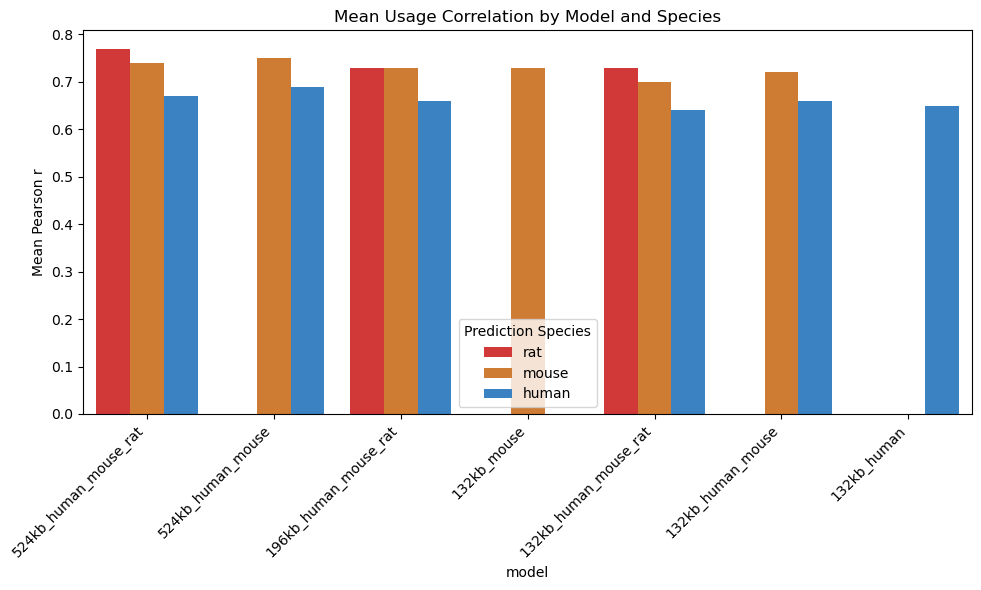

In [40]:
# Subset where usage_head_species and pred_species match
top_summary = overall_summary.reset_index()
top_summary = top_summary[top_summary['usage_head_species'] == top_summary['pred_species']]
# Order by pred_species, then mean correlation
top_summary = top_summary.reset_index()
top_summary = top_summary.sort_values(by=['mean'], ascending=[False])
# Subset columns to show
top_summary = top_summary[['model', 'pred_species', 'mean', 'std']]
display(top_summary)

import seaborn as sns
SPECIES_COLORS = {
    'human': "#2383d8",
    'mouse': "#e77a1b",
    'rat': "#ea1f1f"
}
# Plot as barplot with error bars
plt.figure(figsize=(10, 6))
sns.barplot(data=top_summary, x='model', y='mean', hue='pred_species', palette=SPECIES_COLORS, capsize=0.1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Pearson r')  
plt.title('Mean Usage Correlation by Model and Species')
plt.legend(title='Prediction Species')
plt.tight_layout()
plt.show()